In [48]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [10]:
PROJECT_ID = "project-eba4607b-9314-4a56-97d"
client = bigquery.Client(project=PROJECT_ID)

In [11]:
# Generalized query function
job_config = bigquery.QueryJobConfig(
    maximum_bytes_billed=10 * 1024**3  # 10 GB limit
)

def run_query(sql: str) -> pd.DataFrame:
    """Run a SQL query against BigQuery and return a pandas DataFrame."""
    return client.query(sql, job_config=job_config).to_dataframe()

In [14]:
# View all datasets I have access to
datasets = list(client.list_datasets(project="physionet-data"))
for d in datasets:
    print(d.dataset_id)

mimiciv_3_1_derived
mimiciv_3_1_hosp
mimiciv_3_1_icu


In [27]:
"""
Query 1 - Percent conversion from hospital stay to ICU stay by gender, insurance type, and race
"""

# First check all distinct races so I can clean the data
query1_df = run_query("""
    SELECT DISTINCT race
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
    ORDER BY race
""")

query1_df

query1_df = run_query("""

WITH race_bucketed AS (
    -- Consolidate the raw race categories into more general groups
    SELECT
        hadm_id,
        subject_id,
        insurance,
        admittime,
        dischtime,
        CASE
            WHEN race LIKE '%ASIAN%' THEN 'Asian'
            WHEN race LIKE '%BLACK%' THEN 'Black'
            WHEN race LIKE '%HISPANIC%' THEN 'Hispanic/Latino'
            WHEN race LIKE '%WHITE%' THEN 'White'
            WHEN race = 'AMERICAN INDIAN/ALASKA NATIVE' THEN 'American Indian/Alaska Native'
            WHEN race = 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER' THEN 'Native Hawaiian/Pacific Islander'
            WHEN race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') THEN 'Unknown/Declined'
            ELSE 'Other'  -- catches MULTIPLE RACE/ETHNICITY, OTHER, PORTUGUESE, SOUTH AMERICAN
        END AS race_group
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
),

patient_demo AS (
    -- Join in gender, compute length of stay in days as demographics table
    SELECT
        r.hadm_id,
        r.subject_id,
        r.insurance,
        r.race_group,
        p.gender
    FROM race_bucketed r
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
        ON r.subject_id = p.subject_id
    WHERE r.dischtime > r.admittime  -- Filter out any unrealistic length of stays
),

icu_flag AS (
    -- Get hospital IDs from ICU table to determine if a hospital stay converted
    SELECT DISTINCT hadm_id
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
),

admission_icu AS (
    -- Flag each admission as ICU or not 
    SELECT
        d.gender,
        d.insurance,
        d.race_group,
        CASE WHEN i.hadm_id IS NOT NULL THEN 1 ELSE 0 END AS had_icu_stay
    FROM patient_demo d
    LEFT JOIN icu_flag i ON d.hadm_id = i.hadm_id
)

-- Aggregate the flags into statistics
SELECT
    gender,
    insurance,
    race_group,
    COUNT(*) AS n_admissions,
    SUM(had_icu_stay) AS n_icu_admissions,
    ROUND(SUM(had_icu_stay) / COUNT(*), 2) AS icu_conversion_rate
FROM admission_icu
GROUP BY gender, insurance, race_group
ORDER BY icu_conversion_rate DESC

""")

query1_df

C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,gender,insurance,race_group,n_admissions,n_icu_admissions,icu_conversion_rate
0,M,Medicare,Unknown/Declined,4217,2619,0.62
1,F,Medicare,Unknown/Declined,3772,2059,0.55
2,M,Medicaid,Unknown/Declined,1795,976,0.54
3,M,Private,Unknown/Declined,3406,1722,0.51
4,M,None,Unknown/Declined,689,353,0.51
...,...,...,...,...,...,...
87,F,None,American Indian/Alaska Native,4,0,0.00
88,M,No charge,Black,37,0,0.00
89,F,No charge,Unknown/Declined,22,0,0.00
90,F,No charge,Asian,10,0,0.00


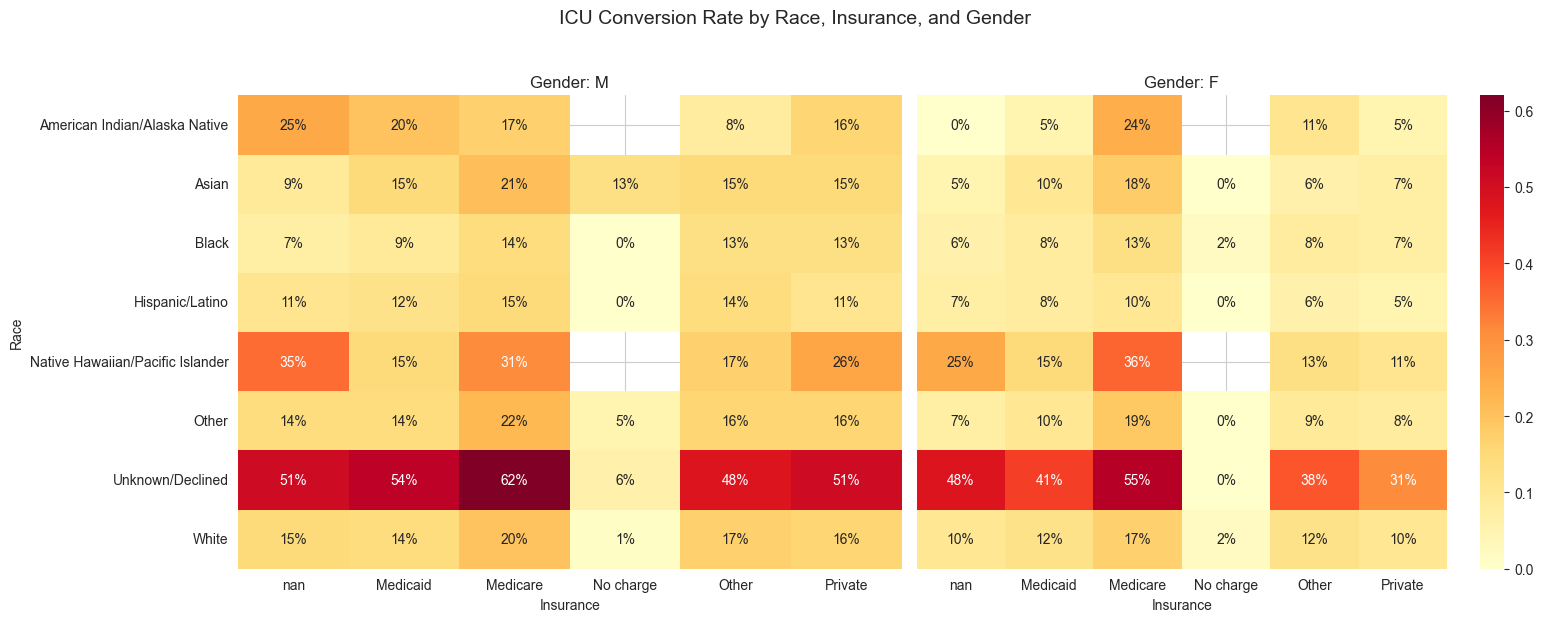

In [51]:
# Pivot into a race x insurance grid, one heatmap per gender
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, gender in zip(axes, ['M', 'F']):
    subset = query1_df[query1_df['gender'] == gender]
    pivot = subset.pivot(index='race_group', columns='insurance', values='icu_conversion_rate')

    sns.heatmap(
        pivot,
        annot=True,
        fmt='.0%',
        cmap='YlOrRd',
        ax=ax,
        cbar=gender == 'F',  # only show one colorbar to avoid duplication
        vmin=0, vmax=query1_df['icu_conversion_rate'].max()
    )
    ax.set_title(f"Gender: {gender}")
    ax.set_xlabel("Insurance")
    ax.set_ylabel("Race" if gender == 'M' else "")

plt.suptitle("ICU Conversion Rate by Race, Insurance, and Gender", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
"""
Query 2 - Intensity of charting/leb events during hospital stay by gender, insurance type, and race
"""

# First check all distinct races so I can clean the data
query2_df = run_query("""
    SELECT DISTINCT race
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
    ORDER BY race
""")

query2_df

query2_df = run_query("""

WITH race_bucketed AS (
    -- Consolidate the raw race categories into more general groups
    SELECT
        hadm_id,
        subject_id,
        insurance,
        admittime,
        dischtime,
        CASE
            WHEN race LIKE '%ASIAN%' THEN 'Asian'
            WHEN race LIKE '%BLACK%' THEN 'Black'
            WHEN race LIKE '%HISPANIC%' THEN 'Hispanic/Latino'
            WHEN race LIKE '%WHITE%' THEN 'White'
            WHEN race = 'AMERICAN INDIAN/ALASKA NATIVE' THEN 'American Indian/Alaska Native'
            WHEN race = 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER' THEN 'Native Hawaiian/Pacific Islander'
            WHEN race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') THEN 'Unknown/Declined'
            ELSE 'Other'  -- catches MULTIPLE RACE/ETHNICITY, OTHER, PORTUGUESE, SOUTH AMERICAN
        END AS race_group
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
),

patient_demo AS (
    -- Join in gender, compute length of stay in days as demographics table
    SELECT
        r.hadm_id,
        r.subject_id,
        r.insurance,
        r.race_group,
        p.gender,
        DATETIME_DIFF(r.dischtime, r.admittime, HOUR) / 24.0 AS los_days
    FROM race_bucketed r
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
        ON r.subject_id = p.subject_id
    WHERE r.dischtime > r.admittime  -- Filter out any unrealistic length of stays
),

chart_counts AS (
    -- Get ICU chart events per hospital admission
    SELECT hadm_id, COUNT(*) AS chartevents
    FROM `physionet-data.mimiciv_3_1_icu.chartevents`
    GROUP BY hadm_id
),

lab_counts AS (
    -- Get lab events per hospital admission
    SELECT hadm_id, COUNT(*) AS labevents
    FROM `physionet-data.mimiciv_3_1_hosp.labevents`
    WHERE hadm_id IS NOT NULL
    GROUP BY hadm_id
),

stay_intensity AS (
    -- Combine demographics, chart count, and lab count CTEs
    SELECT
        d.hadm_id,
        d.gender,
        d.insurance,
        d.race_group,
        d.los_days,
        IFNULL(c.chartevents, 0) + IFNULL(l.labevents, 0) AS total_events,
        (IFNULL(c.chartevents, 0) + IFNULL(l.labevents, 0)) / NULLIF(d.los_days, 0) AS events_per_day
    FROM patient_demo d
    LEFT JOIN chart_counts c ON d.hadm_id = c.hadm_id
    LEFT JOIN lab_counts l ON d.hadm_id = l.hadm_id
)

-- Aggregate data into final result
SELECT
    gender,
    insurance,
    race_group,
    COUNT(*) AS n_admissions,
    ROUND(AVG(total_events), 1) AS avg_total_events,
    ROUND(AVG(events_per_day), 1) AS avg_events_per_day,
    ROUND(AVG(los_days), 1) AS avg_los_days
FROM stay_intensity
GROUP BY gender, insurance, race_group
ORDER BY avg_events_per_day DESC

""")

query2_df

C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,gender,insurance,race_group,n_admissions,avg_total_events,avg_events_per_day,avg_los_days
0,F,None,Unknown/Declined,338,1955.8,647.7,4.1
1,M,None,Unknown/Declined,689,2698.5,646.3,4.4
2,M,Medicare,Unknown/Declined,4217,4468.4,462.5,8.3
3,M,Medicaid,Unknown/Declined,1795,4666.9,444.8,8.9
4,F,Medicare,Unknown/Declined,3772,3928.3,422.2,7.8
...,...,...,...,...,...,...,...
87,F,No charge,Asian,10,43.8,7.8,2.9
88,M,No charge,Hispanic/Latino,8,6.8,4.7,4.1
89,F,No charge,Unknown/Declined,22,7.4,2.3,1.3
90,F,None,American Indian/Alaska Native,4,5.0,0.3,6.7


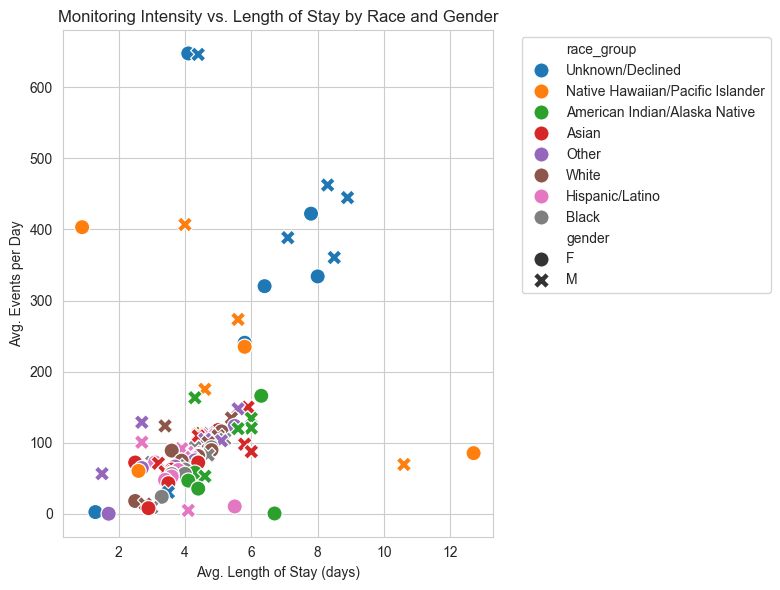

In [50]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=query2_df,
    x="avg_los_days",
    y="avg_events_per_day",
    hue="race_group",
    style="gender",
    s=120
)
plt.title("Monitoring Intensity vs. Length of Stay by Race and Gender")
plt.xlabel("Avg. Length of Stay (days)")
plt.ylabel("Avg. Events per Day")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [28]:
"""
Query 3 - Pain medication administration by gender and race
"""

query3_df = run_query("""

WITH race_bucketed AS (
    -- Consolidate the raw race categories into more general groups
    SELECT
        hadm_id,
        subject_id,
        insurance,
        admittime,
        dischtime,
        CASE
            WHEN race LIKE '%ASIAN%' THEN 'Asian'
            WHEN race LIKE '%BLACK%' THEN 'Black'
            WHEN race LIKE '%HISPANIC%' THEN 'Hispanic/Latino'
            WHEN race LIKE '%WHITE%' THEN 'White'
            WHEN race = 'AMERICAN INDIAN/ALASKA NATIVE' THEN 'American Indian/Alaska Native'
            WHEN race = 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER' THEN 'Native Hawaiian/Pacific Islander'
            WHEN race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') THEN 'Unknown/Declined'
            ELSE 'Other'
        END AS race_group
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
),

patient_demo AS (
    SELECT
        r.hadm_id,
        r.subject_id,fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = [
    ('pct_received_any_pain_med', 'Any Pain Medication'),
    ('pct_received_opioid', 'Opioid Specifically')
]

for ax, (metric, title) in zip(axes, metrics):
    pivot = query3_df.pivot(index='race_group', columns='gender', values=metric)

    sns.heatmap(
        pivot,
        annot=True,
        fmt='.0%',
        cmap='YlOrRd',
        ax=ax,
        cbar=True,
        vmin=0, vmax=1
    )
    ax.set_title(title)
    ax.set_xlabel("Gender")
    ax.set_ylabel("Race" if ax == axes[0] else "")

plt.suptitle("Pain Medication Administration Rate by Gender and Race", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()
        r.race_group,
        p.gender
    FROM race_bucketed r
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
        ON r.subject_id = p.subject_id
    WHERE r.dischtime > r.admittime
),

pain_med_orders AS (
    -- Flag prescription rows matching common pain medications (opioid + non-opioid analgesics)
    SELECT
        hadm_id,
        drug,
        CASE
            WHEN REGEXP_CONTAINS(UPPER(drug), r'MORPHINE|FENTANYL|OXYCODONE|HYDROMORPHONE|HYDROCODONE|TRAMADOL|CODEINE')
                THEN 'Opioid'
            WHEN REGEXP_CONTAINS(UPPER(drug), r'ACETAMINOPHEN|IBUPROFEN|NAPROXEN|KETOROLAC')
                THEN 'Non-opioid analgesic'
            ELSE NULL
        END AS pain_med_class
    FROM `physionet-data.mimiciv_3_1_hosp.prescriptions`
),

pain_med_flagged AS (
    -- Keep only rows that actually matched a pain medication
    SELECT hadm_id, pain_med_class
    FROM pain_med_orders
    WHERE pain_med_class IS NOT NULL
),

admission_pain_counts AS (
    -- Count total pain med orders and opioid-specific orders per admission
    SELECT
        hadm_id,
        COUNT(*) AS n_pain_med_orders,
        COUNTIF(pain_med_class = 'Opioid') AS n_opioid_orders
    FROM pain_med_flagged
    GROUP BY hadm_id
),

admission_pain AS (
    -- Join demographics to pain med order counts
    SELECT
        d.gender,
        d.race_group,
        IFNULL(c.n_pain_med_orders, 0) AS n_pain_med_orders,
        IFNULL(c.n_opioid_orders, 0) AS n_opioid_orders,
        CASE WHEN c.hadm_id IS NOT NULL THEN 1 ELSE 0 END AS received_pain_med,
        CASE WHEN c.n_opioid_orders > 0 THEN 1 ELSE 0 END AS received_opioid
    FROM patient_demo d
    LEFT JOIN admission_pain_counts c ON d.hadm_id = c.hadm_id
)

-- Aggregate into final result: pain med administration rate by gender and race
SELECT
    gender,
    race_group,
    COUNT(*) AS n_admissions,
    ROUND(AVG(received_pain_med), 3) AS pct_received_any_pain_med,
    ROUND(AVG(received_opioid), 3) AS pct_received_opioid,
    ROUND(AVG(n_pain_med_orders), 1) AS avg_pain_med_orders_per_admission,
    ROUND(AVG(n_opioid_orders), 1) AS avg_opioid_orders_per_admission
FROM admission_pain
GROUP BY gender, race_group
ORDER BY pct_received_opioid DESC

""")

query3_df

C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,gender,race_group,n_admissions,pct_received_any_pain_med,pct_received_opioid,avg_pain_med_orders_per_admission,avg_opioid_orders_per_admission
0,M,Unknown/Declined,10649,0.879,0.714,5.8,3.4
1,F,Unknown/Declined,8831,0.903,0.700,5.4,3.0
2,F,White,180105,0.796,0.552,3.8,2.1
3,F,Other,12182,0.787,0.540,3.7,1.9
4,M,American Indian/Alaska Native,567,0.767,0.536,3.7,2.2
5,F,American Indian/Alaska Native,680,0.782,0.524,3.7,1.9
6,M,White,180306,0.752,0.523,3.6,2.2
7,F,Hispanic/Latino,17428,0.755,0.507,3.3,1.7
8,M,Other,11052,0.726,0.502,3.6,2.1
9,M,Native Hawaiian/Pacific Islander,305,0.715,0.498,4.2,2.5


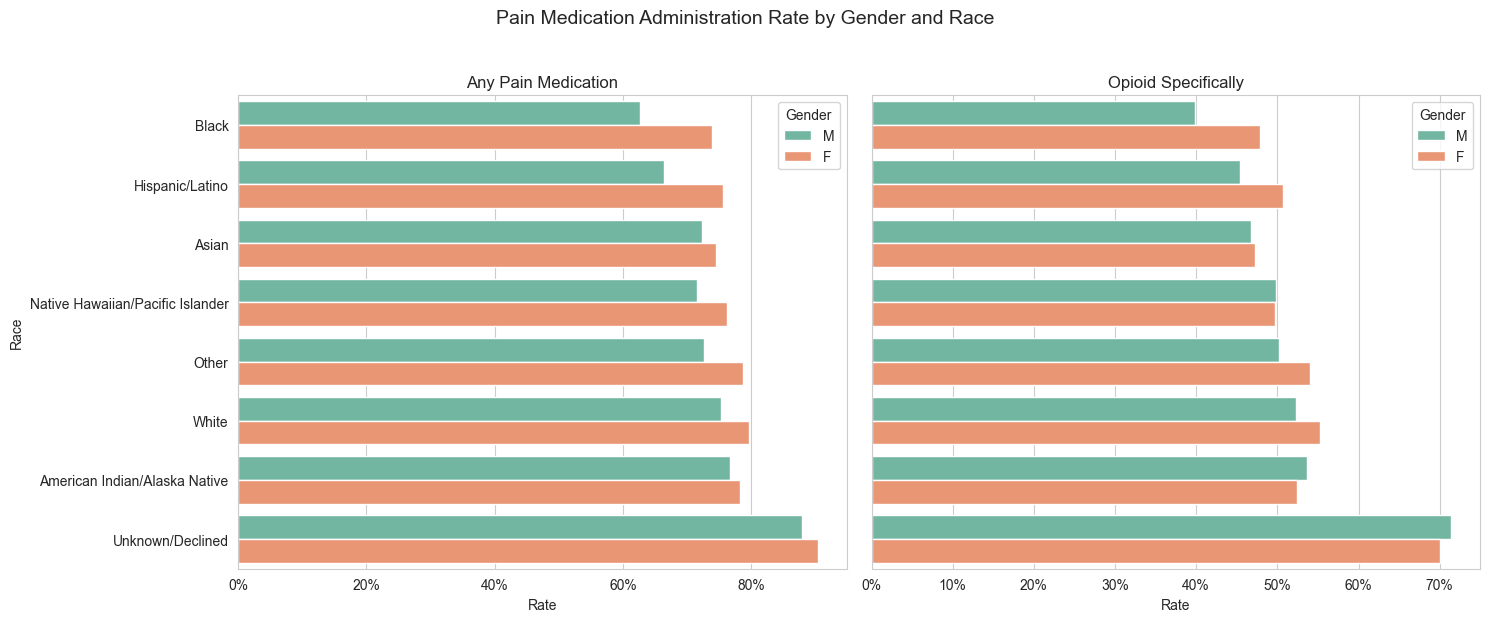

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

metrics = [
    ('pct_received_any_pain_med', 'Any Pain Medication'),
    ('pct_received_opioid', 'Opioid Specifically')
]

# Sort race order by the "any pain med" rate so both panels share a consistent order
race_order = (
    query3_df.groupby('race_group')['pct_received_any_pain_med']
    .mean()
    .sort_values(ascending=True)
    .index
)

for ax, (metric, title) in zip(axes, metrics):
    sns.barplot(
        data=query3_df,
        y='race_group',
        x=metric,
        hue='gender',
        order=race_order,
        palette='Set2',
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Rate")
    ax.set_ylabel("Race" if ax == axes[0] else "")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.legend(title='Gender')

plt.suptitle("Pain Medication Administration Rate by Gender and Race", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
"""
    Query 4 - Rate of mental health diagnosis by gender and race
"""

query4_df = run_query("""

WITH race_bucketed AS (
    -- Consolidate the raw race categories into more general groups
    SELECT
        hadm_id,
        subject_id,
        admittime,
        dischtime,
        CASE
            WHEN race LIKE '%ASIAN%' THEN 'Asian'
            WHEN race LIKE '%BLACK%' THEN 'Black'
            WHEN race LIKE '%HISPANIC%' THEN 'Hispanic/Latino'
            WHEN race LIKE '%WHITE%' THEN 'White'
            WHEN race = 'AMERICAN INDIAN/ALASKA NATIVE' THEN 'American Indian/Alaska Native'
            WHEN race = 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER' THEN 'Native Hawaiian/Pacific Islander'
            WHEN race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') THEN 'Unknown/Declined'
            ELSE 'Other'
        END AS race_group
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
),

patient_demo AS (
    -- Join in gender
    SELECT
        r.hadm_id,
        r.subject_id,
        r.race_group,
        p.gender
    FROM race_bucketed r
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
        ON r.subject_id = p.subject_id
    WHERE r.dischtime > r.admittime
),

mental_health_dx AS (
    -- Flag diagnosis rows that fall in mental/behavioral health ICD ranges
    -- ICD-9: codes 290-319 (Mental Disorders chapter)
    -- ICD-10: codes starting with 'F' (Mental, Behavioral and Neurodevelopmental disorders)
    SELECT DISTINCT
        hadm_id
    FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd`
    WHERE
        (icd_version = 9
            AND SAFE_CAST(LEFT(icd_code, 3) AS INT64) BETWEEN 290 AND 319)
        OR
        (icd_version = 10
            AND LEFT(icd_code, 1) = 'F')
),

admission_flagged AS (
    -- Join demographics to the mental health flag 
    SELECT
        d.hadm_id,
        d.gender,
        d.race_group,
        CASE WHEN m.hadm_id IS NOT NULL THEN 1 ELSE 0 END AS has_mental_health_dx
    FROM patient_demo d
    LEFT JOIN mental_health_dx m ON d.hadm_id = m.hadm_id
)

-- Aggregate into final result of mental health diagnosis rate by gender and race
SELECT
    gender,
    race_group,
    COUNT(*) AS n_admissions,
    SUM(has_mental_health_dx) AS n_with_mental_health_dx,
    ROUND(AVG(has_mental_health_dx), 3) AS pct_with_mental_health_dx
FROM admission_flagged
GROUP BY gender, race_group
ORDER BY pct_with_mental_health_dx DESC

""")

query4_df

C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,gender,race_group,n_admissions,n_with_mental_health_dx,pct_with_mental_health_dx
0,M,Native Hawaiian/Pacific Islander,305,177,0.580
1,M,Black,35582,17598,0.495
2,M,American Indian/Alaska Native,567,279,0.492
3,M,Hispanic/Latino,14774,7168,0.485
4,F,Native Hawaiian/Pacific Islander,189,88,0.466
5,F,White,180105,83401,0.463
6,M,Unknown/Declined,10649,4779,0.449
7,M,White,180306,80454,0.446
8,F,Unknown/Declined,8831,3647,0.413
9,M,Other,11052,4465,0.404


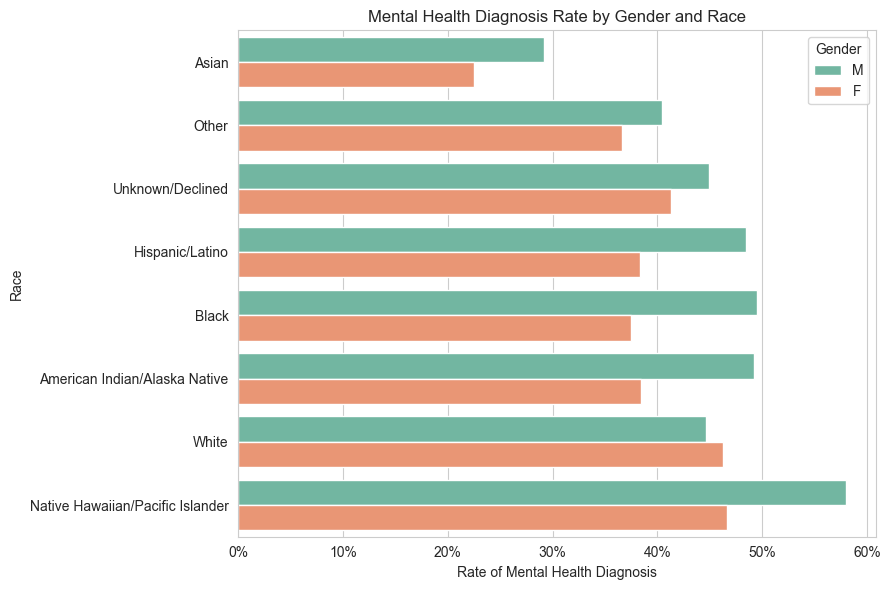

In [54]:
# Sort race order by overall rate for a cleaner visual ranking
race_order = (
    query4_df.groupby('race_group')['pct_with_mental_health_dx']
    .mean()
    .sort_values(ascending=True)
    .index
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=query4_df,
    y='race_group',
    x='pct_with_mental_health_dx',
    hue='gender',
    order=race_order,
    palette='Set2'
)

plt.title("Mental Health Diagnosis Rate by Gender and Race")
plt.xlabel("Rate of Mental Health Diagnosis")
plt.ylabel("Race")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [30]:
"""
Query 5 - Mortality rate by gender and race
"""

query5_df = run_query("""

WITH race_bucketed AS (
    -- Consolidate the raw race categories into more general groups
    SELECT
        hadm_id,
        subject_id,
        admittime,
        dischtime,
        hospital_expire_flag,
        CASE
            WHEN race LIKE '%ASIAN%' THEN 'Asian'
            WHEN race LIKE '%BLACK%' THEN 'Black'
            WHEN race LIKE '%HISPANIC%' THEN 'Hispanic/Latino'
            WHEN race LIKE '%WHITE%' THEN 'White'
            WHEN race = 'AMERICAN INDIAN/ALASKA NATIVE' THEN 'American Indian/Alaska Native'
            WHEN race = 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER' THEN 'Native Hawaiian/Pacific Islander'
            WHEN race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') THEN 'Unknown/Declined'
            ELSE 'Other'
        END AS race_group
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
),

patient_demo AS (
    -- Join in gender
    SELECT
        r.hadm_id,
        r.subject_id,
        r.race_group,
        r.hospital_expire_flag,
        p.gender
    FROM race_bucketed r
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
        ON r.subject_id = p.subject_id
    WHERE r.dischtime > r.admittime
)

-- Aggregate into final result: in-hospital mortality rate by gender and race
SELECT
    gender,
    race_group,
    COUNT(*) AS n_admissions,
    SUM(hospital_expire_flag) AS n_deaths,
    ROUND(AVG(hospital_expire_flag), 3) AS mortality_rate
FROM patient_demo
GROUP BY gender, race_group
ORDER BY mortality_rate DESC

""")

query5_df

C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,gender,race_group,n_admissions,n_deaths,mortality_rate
0,M,Unknown/Declined,10649,1091,0.102
1,F,Unknown/Declined,8831,860,0.097
2,M,Native Hawaiian/Pacific Islander,305,14,0.046
3,F,Native Hawaiian/Pacific Islander,189,8,0.042
4,M,Asian,8603,258,0.030
5,M,White,180306,4033,0.022
6,M,Other,11052,245,0.022
7,F,White,180105,3333,0.019
8,M,American Indian/Alaska Native,567,11,0.019
9,F,American Indian/Alaska Native,680,11,0.016


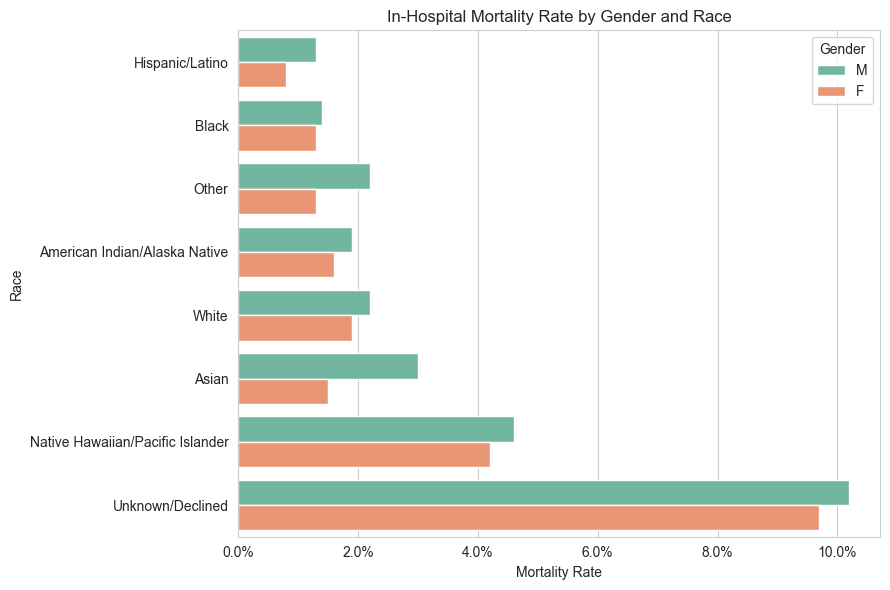

In [55]:
# Sort race order by overall rate for a cleaner visual ranking
race_order = (
    query5_df.groupby('race_group')['mortality_rate']
    .mean()
    .sort_values(ascending=True)
    .index
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=query5_df,
    y='race_group',
    x='mortality_rate',
    hue='gender',
    order=race_order,
    palette='Set2'
)

plt.title("In-Hospital Mortality Rate by Gender and Race")
plt.xlabel("Mortality Rate")
plt.ylabel("Race")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [35]:
"""
Query 6 - Rate of insurance types by unit
"""

# Explore care units
care_units_df = run_query("""
    SELECT DISTINCT first_careunit
    FROM `physionet-data.mimiciv_3_1_icu.icustays`
""")

care_units_df

query6_df = run_query("""

WITH icu_admissions AS (
    SELECT
        i.first_careunit,
        a.insurance
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    JOIN `physionet-data.mimiciv_3_1_hosp.admissions` a
        ON i.hadm_id = a.hadm_id
),

unit_insurance_counts AS (
    SELECT
        first_careunit,
        insurance,
        COUNT(*) AS n_stays
    FROM icu_admissions
    GROUP BY first_careunit, insurance
),

unit_insurance_pct AS (
    SELECT
        first_careunit,
        insurance,
        ROUND(
            n_stays / (SELECT SUM(n_stays) FROM unit_insurance_counts u2 WHERE u2.first_careunit = u.first_careunit) * 100,
            1
        ) AS pct_of_unit
    FROM unit_insurance_counts u
),

pivoted AS (
    SELECT *
    FROM unit_insurance_pct
    PIVOT (
        SUM(pct_of_unit)
        FOR insurance IN ('Medicare', 'Private', 'Medicaid', 'Other', 'None')
    )
)

SELECT
    first_careunit,
    IFNULL(Medicare, 0.0) AS Medicare,
    IFNULL(Private, 0.0) AS Private,
    IFNULL(Medicaid, 0.0) AS Medicaid,
    IFNULL(Other, 0.0) AS Other,
    IFNULL(None, 0.0) AS None
FROM pivoted
ORDER BY first_careunit

""")

query6_df

C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,first_careunit,Medicare,Private,Medicaid,Other,None
0,Cardiac Vascular Intensive Care Unit (CVICU),56.8,30.2,10.4,1.9,0.0
1,Coronary Care Unit (CCU),65.3,21.1,10.6,1.9,0.0
2,Intensive Care Unit (ICU),69.7,15.2,6.1,9.1,0.0
3,Med/Surg,100.0,0.0,0.0,0.0,0.0
4,Medical Intensive Care Unit (MICU),56.1,21.3,18.7,2.3,0.0
5,Medical/Surgical Intensive Care Unit (MICU/SICU),55.0,24.3,17.5,2.3,0.0
6,Medicine,37.5,37.5,25.0,0.0,0.0
7,Medicine/Cardiology Intermediate,100.0,0.0,0.0,0.0,0.0
8,Neuro Intermediate,48.9,32.6,14.8,2.4,0.0
9,Neuro Stepdown,46.8,31.9,17.0,3.0,0.0


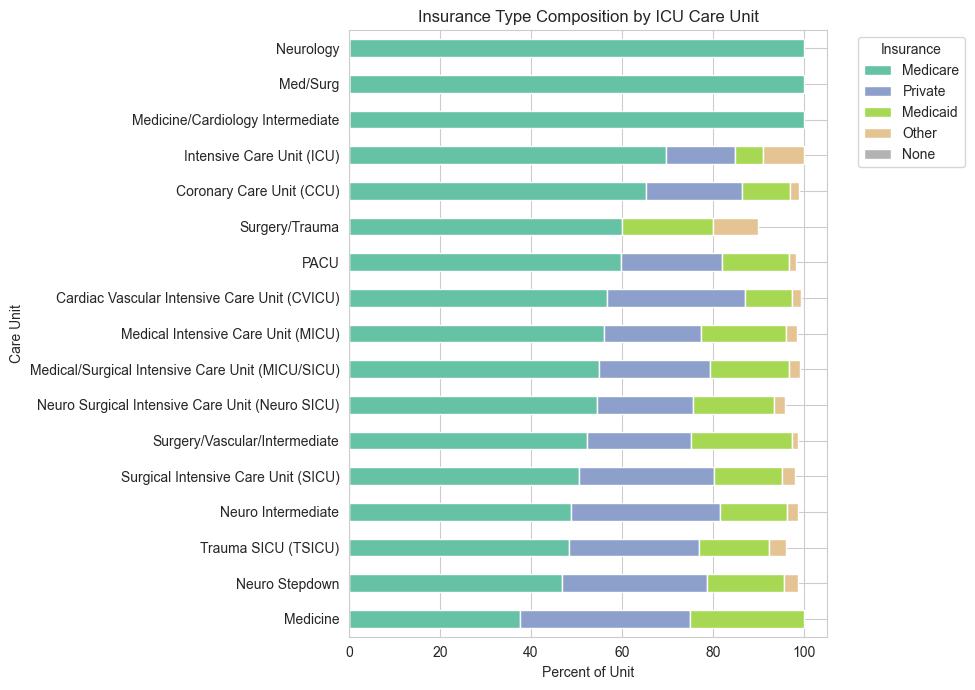

In [56]:
# Set index to care unit, plot columns as stacked bars
plot_df = query6_df.set_index('first_careunit')

# Sort units by their Medicare share for a more readable order (optional)
plot_df = plot_df.sort_values('Medicare', ascending=True)

plot_df.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 7),
    colormap='Set2'
)

plt.title("Insurance Type Composition by ICU Care Unit")
plt.xlabel("Percent of Unit")
plt.ylabel("Care Unit")
plt.legend(title='Insurance', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [41]:
"""
Query 7 - Admission type by gender, race, and insurance type
"""

query7_df = run_query("""

WITH race_bucketed AS (
    SELECT
        hadm_id,
        subject_id,
        insurance,
        admittime,
        dischtime,
        CASE
            WHEN admission_type LIKE '%EMER%' THEN 'Emergency'
            WHEN admission_type = 'URGENT' THEN 'Urgent'
            WHEN admission_type = 'ELECTIVE' THEN 'Elective'
            WHEN admission_type = 'SURGICAL SAME DAY ADMISSION' THEN 'Elective'
            WHEN admission_type LIKE '%OBSERVATION%' THEN 'Observation'
            ELSE 'Other'
        END AS admission_type_group,
        CASE
            WHEN race LIKE '%ASIAN%' THEN 'Asian'
            WHEN race LIKE '%BLACK%' THEN 'Black'
            WHEN race LIKE '%HISPANIC%' THEN 'Hispanic/Latino'
            WHEN race LIKE '%WHITE%' THEN 'White'
            WHEN race = 'AMERICAN INDIAN/ALASKA NATIVE' THEN 'American Indian/Alaska Native'
            WHEN race = 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER' THEN 'Native Hawaiian/Pacific Islander'
            WHEN race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') THEN 'Unknown/Declined'
            ELSE 'Other'
        END AS race_group
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
),

patient_demo AS (
    SELECT
        r.hadm_id,
        r.insurance,
        r.race_group,
        r.admission_type_group,
        p.gender
    FROM race_bucketed r
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
        ON r.subject_id = p.subject_id
    WHERE r.dischtime > r.admittime
),

group_totals AS (
    SELECT
        gender,
        insurance,
        race_group,
        COUNT(*) AS total_admissions
    FROM patient_demo
    GROUP BY gender, insurance, race_group
),

type_counts AS (
    SELECT
        gender,
        insurance,
        race_group,
        admission_type_group,
        COUNT(*) AS n_admissions
    FROM patient_demo
    GROUP BY gender, insurance, race_group, admission_type_group
)

SELECT
    t.gender,
    t.insurance,
    t.race_group,
    t.admission_type_group,
    t.n_admissions,
    g.total_admissions,
    ROUND(t.n_admissions / g.total_admissions * 100, 1) AS pct_of_group
FROM type_counts t
JOIN group_totals g
    ON t.gender = g.gender
    AND t.insurance = g.insurance
    AND t.race_group = g.race_group
ORDER BY t.admission_type_group DESC

""")

query7_df

C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,gender,insurance,race_group,admission_type_group,n_admissions,total_admissions,pct_of_group
0,F,Medicaid,Asian,Urgent,868,3308,26.2
1,F,No charge,Unknown/Declined,Urgent,1,22,4.5
2,F,No charge,Other,Urgent,1,4,25.0
3,M,No charge,Black,Urgent,3,37,8.1
4,F,Medicare,White,Urgent,6345,90618,7.0
...,...,...,...,...,...,...,...
288,F,Other,American Indian/Alaska Native,Elective,2,28,7.1
289,M,Other,American Indian/Alaska Native,Elective,1,38,2.6
290,F,Private,Unknown/Declined,Elective,525,2996,17.5
291,F,Medicare,White,Elective,8864,90618,9.8


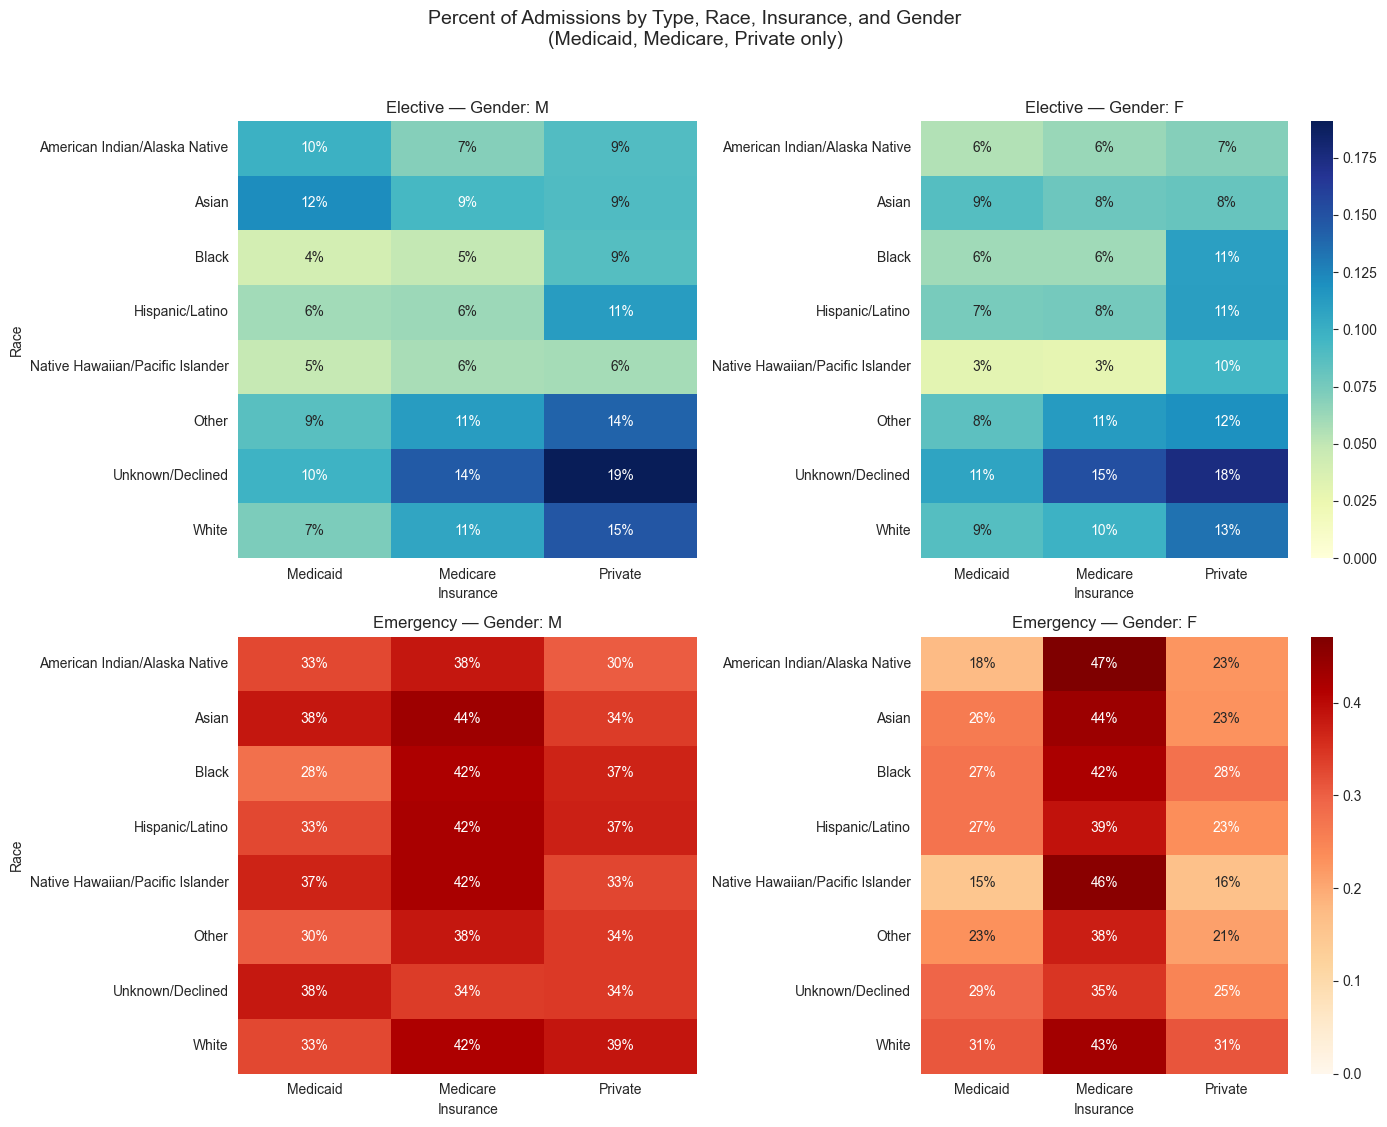

In [59]:
# Keep only the insurance types with meaningful sample sizes
main_insurance = ['Medicaid', 'Medicare', 'Private']
filtered_df = query7_df[query7_df['insurance'].isin(main_insurance)]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

admission_types = ['Elective', 'Emergency']
genders = ['M', 'F']

for row, adm_type in enumerate(admission_types):
    subset_type = filtered_df[filtered_df['admission_type_group'] == adm_type].copy()
    subset_type['pct_of_group'] = subset_type['pct_of_group'] / 100
    vmax = subset_type['pct_of_group'].max()

    for col, gender in enumerate(genders):
        ax = axes[row, col]
        subset = subset_type[subset_type['gender'] == gender]
        pivot = subset.pivot(index='race_group', columns='insurance', values='pct_of_group')

        sns.heatmap(
            pivot,
            annot=True,
            fmt='.0%',
            cmap='YlGnBu' if adm_type == 'Elective' else 'OrRd',
            ax=ax,
            cbar=col == 1,
            vmin=0, vmax=vmax
        )
        ax.set_title(f"{adm_type} — Gender: {gender}")
        ax.set_xlabel("Insurance")
        ax.set_ylabel("Race" if col == 0 else "")

plt.suptitle("Percent of Admissions by Type, Race, Insurance, and Gender\n(Medicaid, Medicare, Private only)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [43]:
"""
Query 8 - Drug use by race and gender
"""

query8_df = run_query("""

WITH race_bucketed AS (
    -- Consolidate the raw race categories into more general groups
    SELECT
        hadm_id,
        subject_id,
        admittime,
        dischtime,
        CASE
            WHEN race LIKE '%ASIAN%' THEN 'Asian'
            WHEN race LIKE '%BLACK%' THEN 'Black'
            WHEN race LIKE '%HISPANIC%' THEN 'Hispanic/Latino'
            WHEN race LIKE '%WHITE%' THEN 'White'
            WHEN race = 'AMERICAN INDIAN/ALASKA NATIVE' THEN 'American Indian/Alaska Native'
            WHEN race = 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER' THEN 'Native Hawaiian/Pacific Islander'
            WHEN race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') THEN 'Unknown/Declined'
            ELSE 'Other'
        END AS race_group
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
),

patient_demo AS (
    -- Join in gender
    SELECT
        r.hadm_id,
        r.race_group,
        p.gender
    FROM race_bucketed r
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
        ON r.subject_id = p.subject_id
    WHERE r.dischtime > r.admittime
),

substance_use_dx AS (
    -- Flag diagnosis rows for substance-use-related disorders
    -- ICD-9: 291-292 (alcohol/drug-induced psychoses), 303-305 (dependence/abuse)
    -- ICD-10: F10-F19 (mental/behavioral disorders due to psychoactive substance use)
    SELECT DISTINCT
        hadm_id
    FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd`
    WHERE
        (icd_version = 9
            AND (
                SAFE_CAST(LEFT(icd_code, 3) AS INT64) BETWEEN 291 AND 292
                OR SAFE_CAST(LEFT(icd_code, 3) AS INT64) BETWEEN 303 AND 305
            ))
        OR
        (icd_version = 10
            AND LEFT(icd_code, 3) BETWEEN 'F10' AND 'F19')
),

admission_flagged AS (
    -- Join demographics to substance use flag (LEFT JOIN keeps admissions with no such diagnosis)
    SELECT
        d.hadm_id,
        d.gender,
        d.race_group,
        CASE WHEN s.hadm_id IS NOT NULL THEN 1 ELSE 0 END AS has_substance_use_dx
    FROM patient_demo d
    LEFT JOIN substance_use_dx s ON d.hadm_id = s.hadm_id
)

-- Aggregate into final result: substance use diagnosis rate by gender and race
SELECT
    gender,
    race_group,
    COUNT(*) AS n_admissions,
    SUM(has_substance_use_dx) AS n_with_substance_use_dx,
    ROUND(AVG(has_substance_use_dx), 3) AS pct_with_substance_use_dx
FROM admission_flagged
GROUP BY gender, race_group
ORDER BY pct_with_substance_use_dx DESC

""")

query8_df

C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,gender,race_group,n_admissions,n_with_substance_use_dx,pct_with_substance_use_dx
0,M,Black,35582,11780,0.331
1,M,Native Hawaiian/Pacific Islander,305,101,0.331
2,M,Hispanic/Latino,14774,4572,0.309
3,M,Unknown/Declined,10649,3014,0.283
4,M,American Indian/Alaska Native,567,153,0.270
5,M,Other,11052,2553,0.231
6,M,White,180306,41118,0.228
7,F,American Indian/Alaska Native,680,117,0.172
8,F,Unknown/Declined,8831,1339,0.152
9,M,Asian,8603,1231,0.143


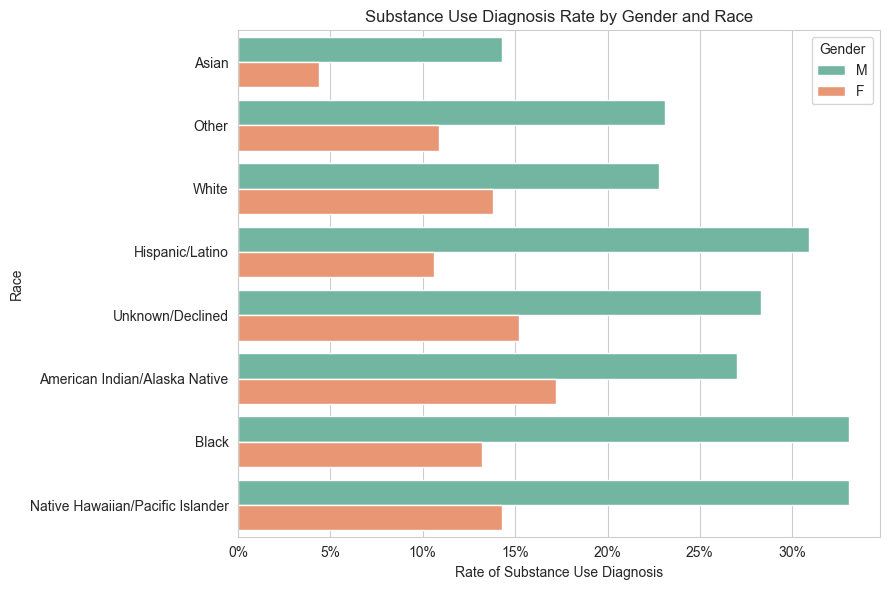

In [60]:
# Sort race order by overall rate for a cleaner visual ranking
race_order = (
    query8_df.groupby('race_group')['pct_with_substance_use_dx']
    .mean()
    .sort_values(ascending=True)
    .index
)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=query8_df,
    y='race_group',
    x='pct_with_substance_use_dx',
    hue='gender',
    order=race_order,
    palette='Set2'
)

plt.title("Substance Use Diagnosis Rate by Gender and Race")
plt.xlabel("Rate of Substance Use Diagnosis")
plt.ylabel("Race")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [64]:
"""
Query 9 - Discharge disposition by race, gender, and insurance
"""

query9_df = run_query("""

WITH race_bucketed AS (
    -- Consolidate the raw race categories into more general groups
    SELECT
        hadm_id,
        subject_id,
        insurance,
        admittime,
        dischtime,
        discharge_location,
        CASE
            WHEN race LIKE '%ASIAN%' THEN 'Asian'
            WHEN race LIKE '%BLACK%' THEN 'Black'
            WHEN race LIKE '%HISPANIC%' THEN 'Hispanic/Latino'
            WHEN race LIKE '%WHITE%' THEN 'White'
            WHEN race = 'AMERICAN INDIAN/ALASKA NATIVE' THEN 'American Indian/Alaska Native'
            WHEN race = 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER' THEN 'Native Hawaiian/Pacific Islander'
            WHEN race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') THEN 'Unknown/Declined'
            ELSE 'Other'
        END AS race_group
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
),

patient_demo AS (
    -- Join in gender, bucket discharge location
    SELECT
        r.hadm_id,
        r.insurance,
        r.race_group,
        p.gender,
        CASE
            WHEN r.discharge_location = 'HOME' THEN 'Home (self)'
            WHEN r.discharge_location = 'HOME HEALTH CARE' THEN 'Home (with care)'
            WHEN r.discharge_location IN ('SKILLED NURSING FACILITY', 'REHAB', 'CHRONIC/LONG TERM ACUTE CARE', 'ASSISTED LIVING') THEN 'Facility care'
            WHEN r.discharge_location = 'HOSPICE' THEN 'Hospice'
            WHEN r.discharge_location = 'DIED' THEN 'Died'
            WHEN r.discharge_location = 'AGAINST ADVICE' THEN 'Against medical advice'
            WHEN r.discharge_location IN ('ACUTE HOSPITAL', 'PSYCH FACILITY', 'OTHER FACILITY', 'HEALTHCARE FACILITY') THEN 'Transferred'
            WHEN r.discharge_location IS NULL THEN 'Unknown/Not recorded'
            ELSE 'Other/Unknown'
        END AS disposition_group
    FROM race_bucketed r
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
        ON r.subject_id = p.subject_id
    WHERE r.dischtime > r.admittime
),

group_totals AS (
    SELECT
        gender,
        insurance,
        race_group,
        COUNT(*) AS total_admissions
    FROM patient_demo
    GROUP BY gender, insurance, race_group
),

disposition_counts AS (
    SELECT
        gender,
        insurance,
        race_group,
        disposition_group,
        COUNT(*) AS n_admissions
    FROM patient_demo
    GROUP BY gender, insurance, race_group, disposition_group
)

SELECT
    d.gender,
    d.insurance,
    d.race_group,
    d.disposition_group,
    d.n_admissions,
    g.total_admissions,
    ROUND(d.n_admissions / g.total_admissions * 100, 1) AS pct_of_group
FROM disposition_counts d
JOIN group_totals g
    ON d.gender = g.gender
    AND d.insurance = g.insurance
    AND d.race_group = g.race_group
ORDER BY d.disposition_group DESC

""")

query9_df

C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,gender,insurance,race_group,disposition_group,n_admissions,total_admissions,pct_of_group
0,F,Private,Hispanic/Latino,Unknown/Not recorded,1327,4055,32.7
1,M,Medicaid,White,Unknown/Not recorded,9809,25223,38.9
2,F,Other,Black,Unknown/Not recorded,403,1180,34.2
3,M,Other,Native Hawaiian/Pacific Islander,Unknown/Not recorded,1,6,16.7
4,F,Private,White,Unknown/Not recorded,17380,62732,27.7
...,...,...,...,...,...,...,...
502,M,Medicaid,Asian,Against medical advice,18,2417,0.7
503,M,Other,Hispanic/Latino,Against medical advice,7,903,0.8
504,F,Private,Other,Against medical advice,9,4489,0.2
505,M,Medicare,Black,Against medical advice,133,13697,1.0


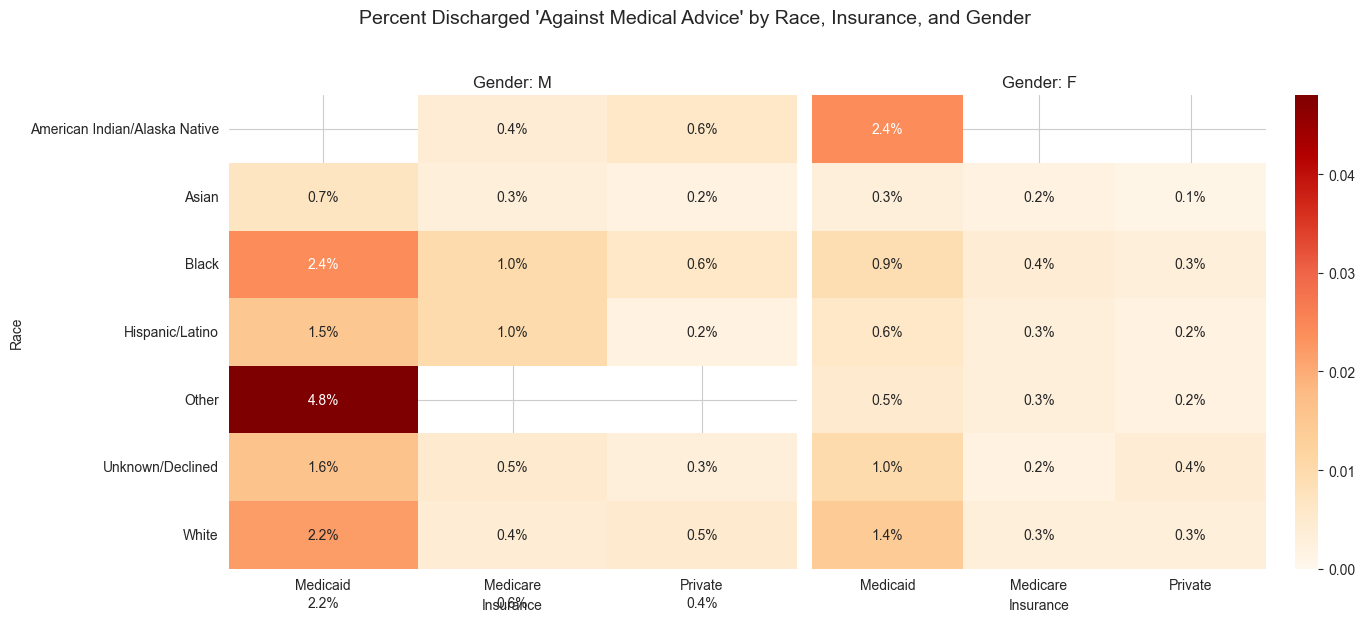

In [65]:
# Filter to main insurance types (avoid the sparse "No charge" issue from before)
main_insurance = ['Medicaid', 'Medicare', 'Private']
ama_df = query9_df[
    (query9_df['disposition_group'] == 'Against medical advice') &
    (query9_df['insurance'].isin(main_insurance))
].copy()
ama_df['pct_of_group'] = ama_df['pct_of_group'] / 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, gender in zip(axes, ['M', 'F']):
    subset = ama_df[ama_df['gender'] == gender]
    pivot = subset.pivot(index='race_group', columns='insurance', values='pct_of_group')

    sns.heatmap(
        pivot,
        annot=True,
        fmt='.1%',
        cmap='OrRd',
        ax=ax,
        cbar=gender == 'F',
        vmin=0, vmax=ama_df['pct_of_group'].max()
    )
    ax.set_title(f"Gender: {gender}")
    ax.set_xlabel("Insurance")
    ax.set_ylabel("Race" if gender == 'M' else "")

plt.suptitle("Percent Discharged 'Against Medical Advice' by Race, Insurance, and Gender", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

In [67]:
"""
Query 10 - 30 day readmission rate by gender, race, and insurance type
"""

query10_df = run_query("""

WITH race_bucketed AS (
    SELECT
        hadm_id,
        subject_id,
        insurance,
        admittime,
        dischtime,
        CASE
            WHEN race LIKE '%ASIAN%' THEN 'Asian'
            WHEN race LIKE '%BLACK%' THEN 'Black'
            WHEN race LIKE '%HISPANIC%' THEN 'Hispanic/Latino'
            WHEN race LIKE '%WHITE%' THEN 'White'
            WHEN race = 'AMERICAN INDIAN/ALASKA NATIVE' THEN 'American Indian/Alaska Native'
            WHEN race = 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER' THEN 'Native Hawaiian/Pacific Islander'
            WHEN race IN ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER') THEN 'Unknown/Declined'
            ELSE 'Other'
        END AS race_group
    FROM `physionet-data.mimiciv_3_1_hosp.admissions`
),

patient_demo AS (
    SELECT
        r.hadm_id,
        r.subject_id,
        r.insurance,
        r.race_group,
        r.admittime,
        r.dischtime,
        p.gender
    FROM race_bucketed r
    JOIN `physionet-data.mimiciv_3_1_hosp.patients` p
        ON r.subject_id = p.subject_id
    WHERE r.dischtime > r.admittime
),

readmission_flagged AS (
    -- Self-join: match each admission to the patient's next-later admission
    SELECT
        d.hadm_id,
        d.gender,
        d.insurance,
        d.race_group,
        CASE
            WHEN MIN(d2.admittime) IS NOT NULL
                AND DATETIME_DIFF(MIN(d2.admittime), d.dischtime, DAY) <= 30
            THEN 1
            ELSE 0
        END AS readmitted_30day
    FROM patient_demo d
    LEFT JOIN patient_demo d2
        ON d.subject_id = d2.subject_id
        AND d2.admittime > d.dischtime
    GROUP BY d.hadm_id, d.gender, d.insurance, d.race_group, d.dischtime
)

SELECT
    gender,
    insurance,
    race_group,
    COUNT(*) AS n_admissions,
    SUM(readmitted_30day) AS n_readmissions,
    ROUND(AVG(readmitted_30day), 3) AS readmission_rate_30day
FROM readmission_flagged
GROUP BY gender, insurance, race_group
ORDER BY readmission_rate_30day DESC

""")

query10_df

C:\Users\laesc\anaconda3\envs\deep-learning\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,gender,insurance,race_group,n_admissions,n_readmissions,readmission_rate_30day
0,F,None,American Indian/Alaska Native,4,2,0.500
1,F,Other,Native Hawaiian/Pacific Islander,8,4,0.500
2,F,No charge,Hispanic/Latino,9,3,0.333
3,F,Other,American Indian/Alaska Native,28,9,0.321
4,M,Medicaid,Black,10937,3443,0.315
...,...,...,...,...,...,...
87,F,None,Unknown/Declined,338,22,0.065
88,M,None,Unknown/Declined,689,34,0.049
89,M,Other,Native Hawaiian/Pacific Islander,6,0,0.000
90,F,None,Native Hawaiian/Pacific Islander,4,0,0.000


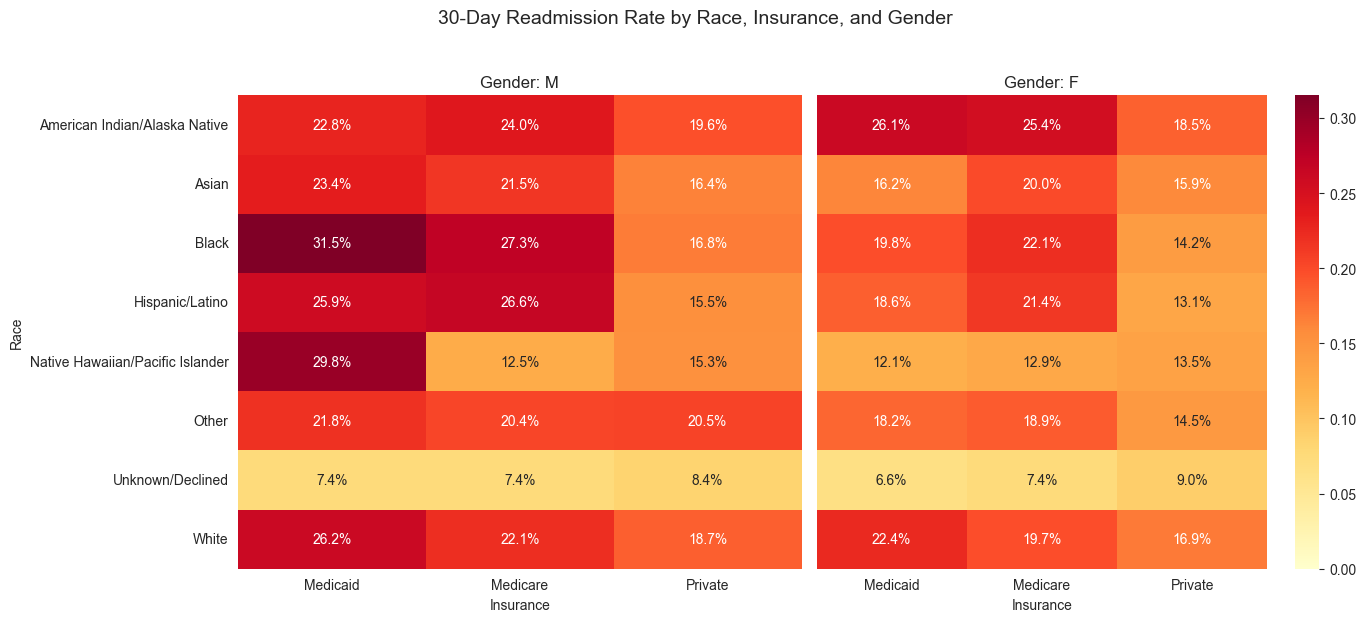

In [68]:
# Filter to main insurance types (avoid sparse "No charge" issue)
main_insurance = ['Medicaid', 'Medicare', 'Private']
readmit_df = query10_df[query10_df['insurance'].isin(main_insurance)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, gender in zip(axes, ['M', 'F']):
    subset = readmit_df[readmit_df['gender'] == gender]
    pivot = subset.pivot(index='race_group', columns='insurance', values='readmission_rate_30day')

    sns.heatmap(
        pivot,
        annot=True,
        fmt='.1%',
        cmap='YlOrRd',
        ax=ax,
        cbar=gender == 'F',
        vmin=0, vmax=readmit_df['readmission_rate_30day'].max()
    )
    ax.set_title(f"Gender: {gender}")
    ax.set_xlabel("Insurance")
    ax.set_ylabel("Race" if gender == 'M' else "")

plt.suptitle("30-Day Readmission Rate by Race, Insurance, and Gender", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()